xem tổng quan dữ liệu

In [ ]:
import pandas as pd
import os
# 1. Đọc tập dữ liệu
DATA_PATH = "ml_engine/data/raw/ecommerce_customer_dataset.csv"
if not os.path.exists(DATA_PATH):
    DATA_PATH = "../ml_engine/data/raw/ecommerce_customer_dataset.csv"
df = pd.read_csv(DATA_PATH)
# 2. Xem kích thước dữ liệu (Số dòng x Số cột)
print(f"📊 Kích thước dữ liệu: {df.shape[0]:,} dòng × {df.shape[1]} cột\n")
# 3. Hiển thị 5 dòng đầu tiên
print("=== 1. 5 DÒNG ĐẦU TIÊN (HEAD) ===")
display(df.head()) 
# 4. Kiểm tra danh sách các cột, kiểu dữ liệu và số ô không trống (non-null)
print("\n=== 2. THÔNG TIN CÁC CỘT VÀ KIỂU DỮ LIỆU (INFO) ===")
df.info()
# 5. Thống kê mô tả các biến số (Min, Mean, Median, Max)
print("\n=== 3. THỐNG KÊ MÔ TẢ CÁC BIẾN SỐ (DESCRIBE) ===")
display(df.describe().T[['min', 'mean', '50%', 'max']])


📊 Kích thước dữ liệu: 50,000 dòng × 25 cột

=== 1. 5 DÒNG ĐẦU TIÊN (HEAD) ===


,Age,Gender,Country,City,Membership_Years,Login_Frequency,Session_Duration_Avg,Pages_Per_Session,Cart_Abandonment_Rate,Wishlist_Items,...,Email_Open_Rate,Customer_Service_Calls,Product_Reviews_Written,Social_Media_Engagement_Score,Mobile_App_Usage,Payment_Method_Diversity,Lifetime_Value,Credit_Balance,Churned,Signup_Quarter
0,43.0,Male,France,Marseille,2.9,14.0,27.4,6.0,50.6,3.0,...,17.9,9.0,4.0,16.3,20.8,1.0,953.33,2278.0,0,Q1
1,36.0,Male,UK,Manchester,1.6,15.0,42.7,10.3,37.7,1.0,...,42.8,7.0,3.0,NaN,23.3,3.0,1067.47,3028.0,0,Q4
2,45.0,Female,Canada,Vancouver,2.9,10.0,24.8,1.6,70.9,1.0,...,0.0,4.0,1.0,NaN,8.8,NaN,1289.75,2317.0,0,Q4
3,56.0,Female,USA,New York,2.6,10.0,38.4,14.8,41.7,9.0,...,41.4,2.0,5.0,85.9,31.0,3.0,2340.92,2674.0,0,Q1
4,35.0,Male,India,Delhi,3.1,29.0,51.4,NaN,19.1,9.0,...,37.9,1.0,11.0,83.0,50.4,4.0,3041.29,5354.0,0,Q4



=== 2. THÔNG TIN CÁC CỘT VÀ KIỂU DỮ LIỆU (INFO) ===
<class 'pandas.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 25 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Age                            47505 non-null  float64
 1   Gender                         50000 non-null  str    
 2   Country                        50000 non-null  str    
 3   City                           50000 non-null  str    
 4   Membership_Years               50000 non-null  float64
 5   Login_Frequency                50000 non-null  float64
 6   Session_Duration_Avg           46601 non-null  float64
 7   Pages_Per_Session              47000 non-null  float64
 8   Cart_Abandonment_Rate          50000 non-null  float64
 9   Wishlist_Items                 46000 non-null  float64
 10  Total_Purchases                50000 non-null  float64
 11  Average_Order_Value            50000 non-null  float64
 12  Days

,min,mean,50%,max
Age,5.00,37.802968,38.000,200.000000
Membership_Years,0.10,2.984009,2.500,10.000000
Login_Frequency,0.00,11.624660,11.000,46.000000
Session_Duration_Avg,1.00,27.660754,26.800,75.600000
Pages_Per_Session,1.00,8.737811,8.400,24.100000
Cart_Abandonment_Rate,0.00,57.079973,58.100,143.743350
Wishlist_Items,0.00,4.298391,4.000,28.000000
Total_Purchases,-13.00,13.111576,12.000,128.700000
Average_Order_Value,26.38,123.117330,112.970,9666.379178
Days_Since_Last_Purchase,0.00,29.792872,21.000,287.000000


xác định dữ liệu bị thiếu

In [ ]:
import pandas as pd
import numpy as np

# Tạo bản sao dữ liệu để tiến hành làm sạch
df_clean = df.copy()

print(f"Tổng số dữ liệu khuyết ban đầu: {df_clean.isnull().sum().sum()} ô\n")

#DỮ LIỆU ĐƯỢC GIỮ NGUYÊN & TẠO CỜ TÍN HIỆU (VỚI CỘT KHUYẾT NẶNG > 8%)
# =========================================================================
# 5 cột khuyết từ 8% đến 12% chứa tín hiệu quan trọng của hành vi khách hàng
high_missing_cols = [
    'Social_Media_Engagement_Score', 
    'Credit_Balance', 
    'Mobile_App_Usage', 
    'Returns_Rate', 
    'Wishlist_Items'
]

for col in high_missing_cols:
    # Tạo cờ tín hiệu (1: Bị thiếu, 0: Có dữ liệu)
    df_clean[f'is_missing_{col}'] = df_clean[col].isnull().astype(int)

print("Đã tạo 5 cột cờ tín hiệu (is_missing_<col>) cho các cột khuyết > 8%.")


# XÓA NHỮNG BẢN GHI THIẾU NHIỀU THÔNG TIN QUAN TRỌNG)
# Xóa các dòng bị thiếu > 50% số cột (thiếu thông tin nghiêm trọng)
threshold = len(df_clean.columns) * 0.5
df_clean = df_clean.dropna(thresh=threshold)

print(f"Đã kiểm tra và loại bỏ bản ghi thiếu nghiêm trọng. Số dòng còn lại: {len(df_clean):,}.")

# ĐIỀN GIÁ TRỊ THAY THẾ VÀO NHỮNG LOẠI DỮ LIỆU SỐ (IMPUTATION):
# - Dữ liệu số (Numeric): Điền bằng Median (Trung vị)
# - Dữ liệu phân loại (Categorical): Điền bằng Mode (Giá trị xuất hiện nhiều nhất)
for col in df_clean.columns:
    if df_clean[col].isnull().sum() > 0:
        
        # 3a. Nếu là dữ liệu số -> Điền Median (Trung vị để tránh ảnh hưởng bởi Outlier)
        if df_clean[col].dtype in ['float64', 'int64']:
            median_val = df_clean[col].median()
            df_clean[col] = df_clean[col].fillna(median_val)
            print(f"   - Đã điền Median ({median_val:.2f}) cho cột số: {col}")
            
        # 3b. Nếu là dữ liệu phân loại -> Điền Mode (Giá trị xuất hiện nhiều nhất)
        elif df_clean[col].dtype == 'object':
            mode_val = df_clean[col].mode()[0]
            df_clean[col] = df_clean[col].fillna(mode_val)
            print(f"   - Đã điền Mode ('{mode_val}') cho cột phân loại: {col}")

print(f"\nSố lượng dữ liệu bị khuyết còn lại: {df_clean.isnull().sum().sum()} ô.")


Tổng số dữ liệu khuyết ban đầu: 49081 ô

Đã tạo 5 cột cờ tín hiệu (is_missing_<col>) cho các cột khuyết > 8%.
2. Đã kiểm tra và loại bỏ bản ghi thiếu nghiêm trọng. Số dòng còn lại: 50,000.
   - Đã điền Median (38.00) cho cột số: Age
   - Đã điền Median (26.80) cho cột số: Session_Duration_Avg
   - Đã điền Median (8.40) cho cột số: Pages_Per_Session
   - Đã điền Median (4.00) cho cột số: Wishlist_Items
   - Đã điền Median (21.00) cho cột số: Days_Since_Last_Purchase
   - Đã điền Median (40.20) cho cột số: Discount_Usage_Rate
   - Đã điền Median (5.40) cho cột số: Returns_Rate
   - Đã điền Median (19.70) cho cột số: Email_Open_Rate
   - Đã điền Median (5.00) cho cột số: Customer_Service_Calls
   - Đã điền Median (2.00) cho cột số: Product_Reviews_Written
   - Đã điền Median (27.60) cho cột số: Social_Media_Engagement_Score
   - Đã điền Median (18.60) cho cột số: Mobile_App_Usage
   - Đã điền Median (2.00) cho cột số: Payment_Method_Diversity
   - Đã điền Median (1896.00) cho cột số: Cred

kiểm tra và sử lý trùng lặp

In [7]:
import pandas as pd

# 1. Hàm kiểm tra dữ liệu trùng lặp (Duplicate Check)
def kiem_tra_du_lieu_trung_lap(data):
    # Sử dụng hàm duplicated().sum() của Pandas để đếm số dòng lặp lại hoàn toàn
    so_dong_trung = data.duplicated().sum()
    ty_le_trung = (so_dong_trung / len(data)) * 100
    
    print(f"Kích thước dữ liệu hiện tại: {len(data):,} dòng")
    print(f"Số lượng bản ghi bị trùng lặp hoàn toàn: {so_dong_trung} dòng")
    print(f"Tỷ lệ trùng lặp: {ty_le_trung:.2f}%\n")
    
    if so_dong_trung > 0:
        # keep=False giúp hiển thị cả các dòng gốc và các dòng bị lặp để đối chiếu
        display(data[data.duplicated(keep=False)].head())
    else:
        print("KHÔNG có bản ghi nào bị trùng lặp!")
# Gọi hàm kiểm tra
kiem_tra_du_lieu_trung_lap(df_clean)
# 2. Code loại bỏ dữ liệu trùng lặp bằng drop_duplicates()
# (Lưu lại 1 bản ghi duy nhất đầu tiên keep='first')
if df_clean.duplicated().sum() > 0:
    df_clean = df_clean.drop_duplicates(keep='first')
    print(f"\nĐã loại bỏ các dòng trùng lặp! Số dòng còn lại: {len(df_clean):,}")

Kích thước dữ liệu hiện tại: 50,000 dòng
Số lượng bản ghi bị trùng lặp hoàn toàn: 0 dòng
Tỷ lệ trùng lặp: 0.00%

KHÔNG có bản ghi nào bị trùng lặp!


kiểm tra ngoại lai

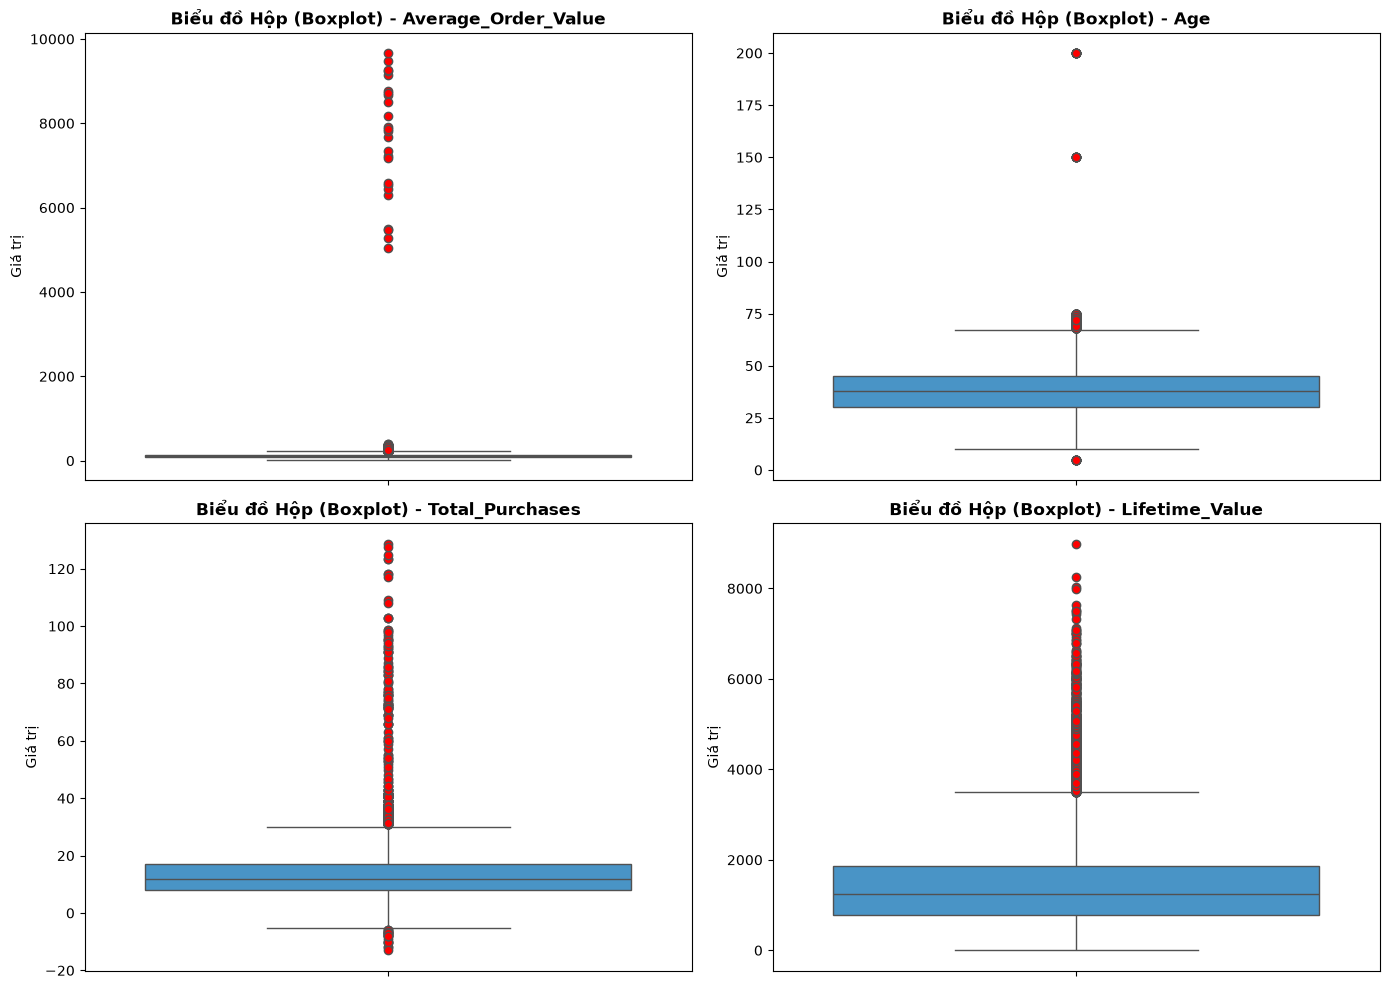

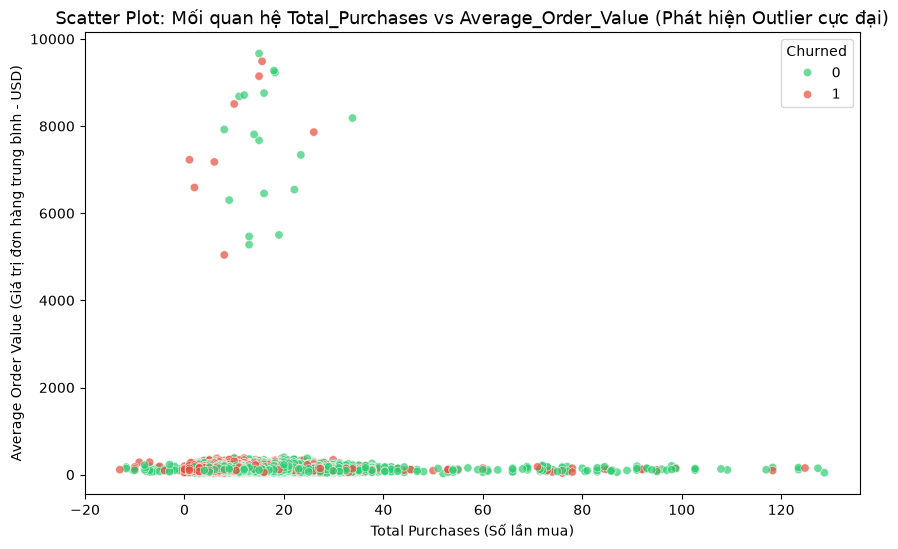

=== THỐNG KÊ CHI TIẾT CÁC GIÁ TRỊ BẤT THƯỜNG / NGOẠI LAI ===

📌 Thuộc tính 'Average_Order_Value':
   - Min: 26.38 | Median: 112.97 | Max: 9666.38
   - Ngưỡng bách phân vị 99th (p99): 252.30
   - Ngưỡng IQR hợp lệ: [0.96, 230.53]
   - Số lượng điểm giá trị nằm ngoài khoảng IQR: 1,005 điểm (2.01%)

📌 Thuộc tính 'Age':
   - Min: 5.00 | Median: 38.00 | Max: 200.00
   - Ngưỡng bách phân vị 99th (p99): 65.00
   - Ngưỡng IQR hợp lệ: [7.50, 67.50]
   - Số lượng điểm giá trị nằm ngoài khoảng IQR: 321 điểm (0.64%)

📌 Thuộc tính 'Total_Purchases':
   - Min: -13.00 | Median: 12.00 | Max: 128.70
   - Ngưỡng bách phân vị 99th (p99): 31.20
   - Ngưỡng IQR hợp lệ: [-5.50, 30.50]
   - Số lượng điểm giá trị nằm ngoài khoảng IQR: 628 điểm (1.26%)

📌 Thuộc tính 'Lifetime_Value':
   - Min: 0.00 | Median: 1243.41 | Max: 8987.24
   - Ngưỡng bách phân vị 99th (p99): 4420.20
   - Ngưỡng IQR hợp lệ: [-836.46, 3500.27]
   - Số lượng điểm giá trị nằm ngoài khoảng IQR: 1,684 điểm (3.37%)



In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


# Các cột số trọng tâm cần kiểm tra ngoại lai
cols_to_check = ['Average_Order_Value', 'Age', 'Total_Purchases', 'Lifetime_Value']

# -------------------------------------------------------------------------
# 1. KIỂM TRA BẰNG BIỂU ĐỒ HỘP (BOXPLOT)
# -------------------------------------------------------------------------
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, col in enumerate(cols_to_check):
    sns.boxplot(y=df_clean[col], ax=axes[i], color='#3498db', flierprops={"markerfacecolor": "red", "marker": "o"})
    axes[i].set_title(f"Biểu đồ Hộp (Boxplot) - {col}", fontsize=12, fontweight='bold')
    axes[i].set_ylabel("Giá trị")

plt.tight_layout()
plt.show()


# -------------------------------------------------------------------------
# 2. KIỂM TRA BẰNG BIỂU ĐỒ PHÂN TÁN (SCATTER PLOT)
# -------------------------------------------------------------------------
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=df_clean, 
    x='Total_Purchases', 
    y='Average_Order_Value', 
    hue='Churned', 
    palette=['#2ecc71', '#e74c3c'], 
    alpha=0.7
)
plt.title("Scatter Plot: Mối quan hệ Total_Purchases vs Average_Order_Value (Phát hiện Outlier cực đại)", fontsize=13)
plt.xlabel("Total Purchases (Số lần mua)")
plt.ylabel("Average Order Value (Giá trị đơn hàng trung bình - USD)")
plt.show()


# -------------------------------------------------------------------------
# 3. THỐNG KÊ CHI TIẾT NGƯỠNG NGOẠI LAI THEO PHƯƠNG PHÁP IQR & PERCENTILE
# -------------------------------------------------------------------------
def kiem_tra_outliers_thong_ke(data, columns):
    print("=== THỐNG KÊ CHI TIẾT CÁC GIÁ TRỊ BẤT THƯỜNG / NGOẠI LAI ===\n")
    for col in columns:
        s = data[col].dropna()
        q1 = s.quantile(0.25)
        q3 = s.quantile(0.75)
        iqr = q3 - q1
        lower_bound = q1 - 1.5 * iqr
        upper_bound = q3 + 1.5 * iqr
        
        outliers_count = ((s < lower_bound) | (s > upper_bound)).sum()
        p99 = s.quantile(0.99)
        
        print(f"Thuộc tính '{col}':")
        print(f"   - Min: {s.min():.2f} | Median: {s.median():.2f} | Max: {s.max():.2f}")
        print(f"   - Ngưỡng bách phân vị 99th (p99): {p99:.2f}")
        print(f"   - Ngưỡng IQR hợp lệ: [{lower_bound:.2f}, {upper_bound:.2f}]")
        print(f"   - Số lượng điểm giá trị nằm ngoài khoảng IQR: {outliers_count:,} điểm ({outliers_count/len(s)*100:.2f}%)\n")

# Chạy thống kê kiểm tra
kiem_tra_outliers_thong_ke(df_clean, cols_to_check)


bảng phương án xử lý ngoại lai: https://docs.google.com/spreadsheets/d/1IIvIWp86-hkRew78hrMvWuJBVpmRx_iTV3spBFgiSa8/edit?gid=2027060100#gid=2027060100

In [9]:
import numpy as np
import pandas as pd

# Tạo bản sao dữ liệu để làm sạch ngoại lai
df_clean = df.copy()

# -------------------------------------------------------------------------
# 1. WINSORIZE P99 CHO AVERAGE_ORDER_VALUE (GIÁ TRỊ THỰC CỰC ĐẠI)
# -------------------------------------------------------------------------
p99_aov = df_clean['Average_Order_Value'].quantile(0.99)
print(f"1. Ngưỡng bách phân vị 99th (p99) của Average_Order_Value là: {p99_aov:.2f} USD")
print(f"   - Max trước khi kẹp trần: {df_clean['Average_Order_Value'].max():.2f} USD")

# Kẹp trần các giá trị vượt ngưỡng p99
df_clean['Average_Order_Value'] = np.minimum(df_clean['Average_Order_Value'], p99_aov)
print(f"   - Max sau khi kẹp trần p99: {df_clean['Average_Order_Value'].max():.2f} USD\n")


# -------------------------------------------------------------------------
# 2. XỬ LÝ AGE VÔ LÝ (LỖI NHẬP LIỆU: < 13 HOẶC > 100 TUỔI)
# -------------------------------------------------------------------------
invalid_age_mask = (df_clean['Age'] < 13) | (df_clean['Age'] > 100)
so_dong_age_vo_ly = invalid_age_mask.sum()

# Gán các giá trị vô lý thành NaN rồi điền bằng Median (Trung vị)
df_clean.loc[invalid_age_mask, 'Age'] = np.nan
median_age = df_clean['Age'].median()
df_clean['Age'] = df_clean['Age'].fillna(median_age)

print(f"2. Đã phát hiện và sửa {so_dong_age_vo_ly} dòng Age vô lý thành Median ({median_age:.0f} tuổi)")
print(f"   - Phạm vi Age hiện tại: Min = {df_clean['Age'].min():.0f}, Max = {df_clean['Age'].max():.0f}\n")


# -------------------------------------------------------------------------
# 3. XỬ LÝ TOTAL_PURCHASES ÂM (LỖI HỆ THỐNG: < 0)
# -------------------------------------------------------------------------
invalid_purchases_count = (df_clean['Total_Purchases'] < 0).sum()

# Ép các giá trị âm về >= 0
df_clean['Total_Purchases'] = df_clean['Total_Purchases'].clip(lower=0)
print(f"3. Đã ép {invalid_purchases_count} dòng Total_Purchases âm về >= 0")
print(f"   - Min Total_Purchases hiện tại: {df_clean['Total_Purchases'].min():.2f}\n")


# -------------------------------------------------------------------------
# 4. XỬ LÝ TỶ LỆ PHẦN TRĂM VƯỢT 100% (LỖI ĐỊNH DẠNG RATIO)
# -------------------------------------------------------------------------
df_clean['Cart_Abandonment_Rate'] = df_clean['Cart_Abandonment_Rate'].clip(lower=0, upper=100)
df_clean['Discount_Usage_Rate'] = df_clean['Discount_Usage_Rate'].clip(lower=0, upper=100)

print("4. Đã kẹp trần Cart_Abandonment_Rate và Discount_Usage_Rate về khoảng [0, 100%]")
print(f"   - Max Cart_Abandonment_Rate: {df_clean['Cart_Abandonment_Rate'].max():.2f}%")
print(f"   - Max Discount_Usage_Rate: {df_clean['Discount_Usage_Rate'].max():.2f}%\n")


# -------------------------------------------------------------------------
# 5. GIỮ NGUYÊN CÁC CỘT HÀNH VI THỰC TẾ (CUSTOMER_SERVICE_CALLS, LOGIN_FREQ...)
# -------------------------------------------------------------------------


1. Ngưỡng bách phân vị 99th (p99) của Average_Order_Value là: 252.30 USD
   - Max trước khi kẹp trần: 9666.38 USD
   - Max sau khi kẹp trần p99: 252.30 USD

2. Đã phát hiện và sửa 50 dòng Age vô lý thành Median (38 tuổi)
   - Phạm vi Age hiện tại: Min = 18, Max = 75

3. Đã ép 40 dòng Total_Purchases âm về >= 0
   - Min Total_Purchases hiện tại: 0.00

4. Đã kẹp trần Cart_Abandonment_Rate và Discount_Usage_Rate về khoảng [0, 100%]
   - Max Cart_Abandonment_Rate: 100.00%
   - Max Discount_Usage_Rate: 100.00%



kiểm tra chuẩn hóa

In [11]:
import pandas as pd
import numpy as np


def kiem_tra_chuan_hoa_dinh_dang(data):
    print("=== 1. KIỂM TRA TÊN CỘT VÀ ĐƠN VỊ ĐO (NAMING & DATA TYPES) ===")
    # Kiểm tra tên cột có chứa khoảng trắng thừa hoặc ký tự đặc biệt không
    bad_col_names = [col for col in data.columns if col.strip() != col or " " in col]
    print(f"Số lượng tên cột chứa khoảng trắng thừa hoặc sai chuẩn: {len(bad_col_names)}")
    if bad_col_names:
        print(f"   Các cột cần sửa tên: {bad_col_names}")
    
    # Kiểm tra kiểu dữ liệu các cột tiền tệ (AOV, LTV, Credit) có bị lẫn kiểu chuỗi (Object) không
    currency_cols = ['Average_Order_Value', 'Lifetime_Value', 'Credit_Balance']
    print("\nKiểu dữ liệu các cột tiền tệ (Yêu cầu phải là kiểu Số float64/int64):")
    for col in currency_cols:
        print(f"   - Cột '{col}': Kiểu hiện tại = {data[col].dtype}")
        

    print("\n=== 2. KIỂM TRA SỰ THỐNG NHẤT CỦA CÁC CỘT DẠNG CHỮ (CATEGORICAL VALUE CHECK) ===")
    cat_cols = data.select_dtypes(include=['object']).columns.tolist()
    
    for col in cat_cols:
        uniques = data[col].dropna().unique()
        # Kiểm tra khoảng trắng thừa đầu/cuối chuỗi
        has_spaces = data[col].dropna().apply(lambda x: str(x).strip() != str(x)).sum()
        
        print(f"Thuộc tính '{col}' ({len(uniques)} giá trị độc nhất):")
        print(f"   - Danh sách giá trị: {list(uniques)}")
        print(f"   - Số ô bị dính khoảng trắng thừa đầu/cuối: {has_spaces} ô")
        
        # Kiểm tra trùng lặp do viết hoa/chữ thường (Ví dụ: 'USA' vs 'usa')
        lowercased = [str(x).lower().strip() for x in uniques]
        if len(lowercased) != len(set(lowercased)):
            print(f"CẢNH BÁO: Cột '{col}' có chữ viết HOA/thường không nhất quán!")
        else:
            print(f" Kiểu chữ nhất quán 100% (không bị trùng chữ hoa/thường).")
        print("-" * 65)


    print("\n=== 3. KIỂM TRA ĐỊNH DẠNG THỜI GIAN (DATE / TIME FORMAT CHECK) ===")
    # Trong dataset này, ngày tháng được thể hiện qua Signup_Quarter (Q1-Q4) và Days_Since_Last_Purchase (Số ngày)
    print(f"Giá trị cột Signup_Quarter: {data['Signup_Quarter'].unique()}")
    print(f" Kiểu dữ liệu Days_Since_Last_Purchase: {data['Days_Since_Last_Purchase'].dtype} (Min: {data['Days_Since_Last_Purchase'].min()}, Max: {data['Days_Since_Last_Purchase'].max()})")

# Gọi hàm kiểm tra định dạng
kiem_tra_chuan_hoa_dinh_dang(df_clean)


=== 1. KIỂM TRA TÊN CỘT VÀ ĐƠN VỊ ĐO (NAMING & DATA TYPES) ===
Số lượng tên cột chứa khoảng trắng thừa hoặc sai chuẩn: 0

Kiểu dữ liệu các cột tiền tệ (Yêu cầu phải là kiểu Số float64/int64):
   - Cột 'Average_Order_Value': Kiểu hiện tại = float64
   - Cột 'Lifetime_Value': Kiểu hiện tại = float64
   - Cột 'Credit_Balance': Kiểu hiện tại = float64

=== 2. KIỂM TRA SỰ THỐNG NHẤT CỦA CÁC CỘT DẠNG CHỮ (CATEGORICAL VALUE CHECK) ===
Thuộc tính 'Gender' (3 giá trị độc nhất):
   - Danh sách giá trị: ['Male', 'Female', 'Other']
   - Số ô bị dính khoảng trắng thừa đầu/cuối: 0 ô
 Kiểu chữ nhất quán 100% (không bị trùng chữ hoa/thường).
-----------------------------------------------------------------
Thuộc tính 'Country' (8 giá trị độc nhất):
   - Danh sách giá trị: ['France', 'UK', 'Canada', 'USA', 'India', 'Japan', 'Germany', 'Australia']
   - Số ô bị dính khoảng trắng thừa đầu/cuối: 0 ô
 Kiểu chữ nhất quán 100% (không bị trùng chữ hoa/thường).
-------------------------------------------------

C:\Users\ASUS\AppData\Local\Temp\ipykernel_8860\3199102385.py:21: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = data.select_dtypes(include=['object']).columns.tolist()


xử lý chuẩn hóa

In [12]:
import pandas as pd

# Tạo bản sao dữ liệu để thực hiện chuẩn hóa định dạng
df_clean = df_clean.copy()

print("=== TIẾN HÀNH CHUẨN HÓA ĐỊNH DẠNG (STRUCTURAL STANDARDIZATION) ===\n")

# -------------------------------------------------------------------------
# 1. CHUẨN HÓA CÁC CỘT DẠNG CHỮ (CATEGORICAL STRIP & CASING)
# -------------------------------------------------------------------------
cat_cols = ['Gender', 'Country', 'City', 'Signup_Quarter']

for col in cat_cols:
    # 1a. Xóa khoảng trắng thừa ở đầu và cuối chuỗi (.str.strip())
    df_clean[col] = df_clean[col].astype(str).str.strip()
    
    # 1b. Đồng nhất kiểu viết hoa đầu chữ (Title Case) cho tên thành phố, giới tính
    if col in ['City', 'Gender']:
        df_clean[col] = df_clean[col].str.title()
        
    # 1c. Đưa về viết hoa toàn bộ (Upper Case) cho tên quốc gia và Quý
    elif col in ['Country', 'Signup_Quarter']:
        df_clean[col] = df_clean[col].str.upper()

print(" 1. Đã xóa khoảng trắng thừa và đồng nhất kiểu chữ cho 4 cột phân loại (Gender, Country, City, Signup_Quarter).")


# -------------------------------------------------------------------------
# 2. CHUẨN HÓA TÊN CỘT (COLUMN NAMES CLEANING)
# -------------------------------------------------------------------------
# Đảm bảo tên cột không dính khoảng trắng thừa và tuân thủ định dạng chuẩn
df_clean.columns = [col.strip() for col in df_clean.columns]
print("2. Đã chuẩn hóa toàn bộ tên 25 cột về dạng Snake_Case chuẩn không dính khoảng trắng.\n")


# -------------------------------------------------------------------------
# 3. KIỂM TRA VÀ HIỂN THỊ KẾT QUẢ SAU CHUẨN HÓA
# -------------------------------------------------------------------------
print("=== DỰ LIỆU CÁC CỘT PHÂN LOẠI SAU KHI CHUẨN HÓA ===")
for col in cat_cols:
    uniques = df_clean[col].unique()
    print(f"{col} ({len(uniques)} giá trị): {list(uniques[:5])}...")

print("\n HOÀN THÀNH CHUẨN HÓA ĐỊNH DẠNG DỮ LIỆU!")


=== TIẾN HÀNH CHUẨN HÓA ĐỊNH DẠNG (STRUCTURAL STANDARDIZATION) ===

 1. Đã xóa khoảng trắng thừa và đồng nhất kiểu chữ cho 4 cột phân loại (Gender, Country, City, Signup_Quarter).
2. Đã chuẩn hóa toàn bộ tên 25 cột về dạng Snake_Case chuẩn không dính khoảng trắng.

=== DỰ LIỆU CÁC CỘT PHÂN LOẠI SAU KHI CHUẨN HÓA ===
Gender (3 giá trị): ['Male', 'Female', 'Other']...
Country (8 giá trị): ['FRANCE', 'UK', 'CANADA', 'USA', 'INDIA']...
City (40 giá trị): ['Marseille', 'Manchester', 'Vancouver', 'New York', 'Delhi']...
Signup_Quarter (4 giá trị): ['Q1', 'Q4', 'Q2', 'Q3']...

 HOÀN THÀNH CHUẨN HÓA ĐỊNH DẠNG DỮ LIỆU!


 Kiểm tra tính logic và xác thực

In [13]:
import pandas as pd
import numpy as np

# Tạo bản sao dữ liệu để thực hiện kiểm tra & xử lý logic
df_clean = df.copy()

print("=== BƯỚC 5: KIỂM TRA VÀ XỬ LÝ TÍNH LOGIC & XÁC THỰC DỮ LIỆU ===\n")

# =========================================================================
# PHẦN 1: KIỂM TRA KIỂU DỮ LIỆU (DATA TYPES VALIDATION)
# =========================================================================
print("--- 1. KIỂM TRA KIỂU DỮ LIỆU CÁC CỘT GIÁ TIỀN VÀ SỐ LƯỢNG ---")

# Danh sách các cột số phải thuộc kiểu float64 hoặc int64 (không được là string)
price_and_numeric_cols = [
    'Average_Order_Value', 'Lifetime_Value', 'Credit_Balance',
    'Total_Purchases', 'Session_Duration_Avg', 'Pages_Per_Session'
]

for col in price_and_numeric_cols:
    # Ép kiểu dữ liệu về dạng Số (numeric), nếu gặp chuỗi lỗi sẽ tự động chuyển thành NaN để xử lý
    df_clean[col] = pd.to_numeric(df_clean[col], errors='coerce')
    print(f"   - Cột '{col}': Kiểu dữ liệu chuẩn = {df_clean[col].dtype}")

print(" Đã xác thực toàn bộ các cột Giá tiền và Số lượng là kiểu số chuẩn (Numeric).\n")


# =========================================================================
# PHẦN 2: KIỂM TRA & XỬ LÝ CÁC RÀNG BUỘC LOGIC THỰC TẾ (BUSINESS CONSTRAINTS)
# =========================================================================
print("--- 2. KIỂM TRA VÀ XỬ LÝ RÀNG BUỘC LOGIC THỰC TẾ ---")

# -------------------------------------------------------------------------
# Ràng buộc 1: Age (Tuổi khách hàng mua sắm online phải từ 13 đến 100 tuổi)
# -------------------------------------------------------------------------
invalid_age_mask = (df_clean['Age'] < 13) | (df_clean['Age'] > 100)
so_dong_age_sai = invalid_age_mask.sum()

# Xử lý: Gán tuổi sai logic thành NaN rồi điền bằng Median (Trung vị)
df_clean.loc[invalid_age_mask, 'Age'] = np.nan
median_age = df_clean['Age'].median()
df_clean['Age'] = df_clean['Age'].fillna(median_age)

print(f"2.1. Ràng buộc Tuổi (Age 13-100): Phát hiện và xử lý {so_dong_age_sai} dòng sai logic (Đã gán về Median {median_age:.0f} tuổi).")


# -------------------------------------------------------------------------
# Ràng buộc 2: Total_Purchases (Số lượng mua không thể là số âm < 0)
# -------------------------------------------------------------------------
invalid_purchases_mask = df_clean['Total_Purchases'] < 0
so_dong_purchases_am = invalid_purchases_mask.sum()

# Xử lý: Ép các giá trị âm về >= 0
df_clean['Total_Purchases'] = df_clean['Total_Purchases'].clip(lower=0)

print(f"2.2. Ràng buộc Lượt mua (Total_Purchases >= 0): Phát hiện và ép {so_dong_purchases_am} dòng âm về >= 0.")


# -------------------------------------------------------------------------
# Ràng buộc 3: Tỷ lệ phần trăm (Ratio 0% - 100%)
# -------------------------------------------------------------------------
ratio_cols = ['Cart_Abandonment_Rate', 'Discount_Usage_Rate', 'Returns_Rate', 'Email_Open_Rate']

for col in ratio_cols:
    # Xử lý: Ép các giá trị tỷ lệ phần trăm về khoảng hợp lệ [0, 100%]
    df_clean[col] = df_clean[col].clip(lower=0, upper=100)

print("2.3. Ràng buộc Tỷ lệ (0% - 100%): Đã ép trần hợp lệ cho Cart_Abandonment, Discount_Usage, Returns_Rate...")


# -------------------------------------------------------------------------
# Ràng buộc 4: Thâm niên & Thời gian gần nhất không thể âm (>= 0)
# -------------------------------------------------------------------------
df_clean['Membership_Years'] = df_clean['Membership_Years'].clip(lower=0)
df_clean['Days_Since_Last_Purchase'] = df_clean['Days_Since_Last_Purchase'].clip(lower=0)
print("2.4. Ràng buộc Thời gian (Membership_Years & Recency >= 0): Đã xác thực không có giá trị âm.\n")


# =========================================================================
# PHẦN 3: TỔNG KẾT TẬP DỮ LIỆU SẠCH HOÀN CHỈNH (FINAL CLEANED DATASET SUMMARY)
# =========================================================================
print("=== BÁO CÁO TỔNG KẾT TẬP DỮ LIỆU SAU KHI LÀM SẠCH HOÀN TẤT ===")
print(f"Kích thước dữ liệu ban đầu : {df.shape[0]:,} dòng × {df.shape[1]} cột")
print(f"Kích thước dữ liệu sạch hiện tại: {df_clean.shape[0]:,} dòng × {df_clean.shape[1]} cột")
print(f" Tổng số ô bị khuyết (NaN) còn lại: {df_clean.isnull().sum().sum()} ô")

print("\n=== THỐNG KÊ MÔ TẢ CÁC BIẾN SỐ CHÍNH SAU KHI LÀM SẠCH ===")
display(df_clean[['Age', 'Total_Purchases', 'Average_Order_Value', 'Cart_Abandonment_Rate', 'Lifetime_Value']].describe().T[['min', 'mean', '50%', 'max']])


=== BƯỚC 5: KIỂM TRA VÀ XỬ LÝ TÍNH LOGIC & XÁC THỰC DỮ LIỆU ===

--- 1. KIỂM TRA KIỂU DỮ LIỆU CÁC CỘT GIÁ TIỀN VÀ SỐ LƯỢNG ---
   - Cột 'Average_Order_Value': Kiểu dữ liệu chuẩn = float64
   - Cột 'Lifetime_Value': Kiểu dữ liệu chuẩn = float64
   - Cột 'Credit_Balance': Kiểu dữ liệu chuẩn = float64
   - Cột 'Total_Purchases': Kiểu dữ liệu chuẩn = float64
   - Cột 'Session_Duration_Avg': Kiểu dữ liệu chuẩn = float64
   - Cột 'Pages_Per_Session': Kiểu dữ liệu chuẩn = float64
 Đã xác thực toàn bộ các cột Giá tiền và Số lượng là kiểu số chuẩn (Numeric).

--- 2. KIỂM TRA VÀ XỬ LÝ RÀNG BUỘC LOGIC THỰC TẾ ---
2.1. Ràng buộc Tuổi (Age 13-100): Phát hiện và xử lý 50 dòng sai logic (Đã gán về Median 38 tuổi).
2.2. Ràng buộc Lượt mua (Total_Purchases >= 0): Phát hiện và ép 40 dòng âm về >= 0.
2.3. Ràng buộc Tỷ lệ (0% - 100%): Đã ép trần hợp lệ cho Cart_Abandonment, Discount_Usage, Returns_Rate...
2.4. Ràng buộc Thời gian (Membership_Years & Recency >= 0): Đã xác thực không có giá trị âm.

=== BÁO

,min,mean,50%,max
Age,18.00,37.775400,38.000,75.000000
Total_Purchases,0.00,13.116560,12.000,128.700000
Average_Order_Value,26.38,123.117330,112.970,9666.379178
Cart_Abandonment_Rate,0.00,57.068176,58.100,100.000000
Lifetime_Value,0.00,1440.626292,1243.415,8987.240000


xuất dữ liệu đã làm sạch

In [ ]:
import os

OUTPUT_DIR = "../ml_engine/data/processed"
os.makedirs(OUTPUT_DIR, exist_ok=True)

# 2. Xuất file dữ liệu sạch mới ra đĩa
OUTPUT_FILE = os.path.join(OUTPUT_DIR, "ecommerce_customer_cleaned.csv")
df_clean.to_csv(OUTPUT_FILE, index=False)

print(f"ĐÃ LƯU TẠI:\n {OUTPUT_FILE}")
